In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)


In [ ]:
# Load the dataset
df = pd.read_csv("/content/student_performance_dataset.csv")

print(f'[INFO] Missing values: {df.isnull().sum().sum()}')
df.head()

[INFO] Missing values: 0


,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


In [ ]:
print(' DATA TYPES & MISSING VALUES ')
print(df.info())
print('\n STATISTICAL SUMMARY ')
df.describe()

 DATA TYPES & MISSING VALUES 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  708 non-null    object 
 1   Gender                      708 non-null    object 
 2   Study_Hours_per_Week        708 non-null    int64  
 3   Attendance_Rate             708 non-null    float64
 4   Past_Exam_Scores            708 non-null    int64  
 5   Parental_Education_Level    708 non-null    object 
 6   Internet_Access_at_Home     708 non-null    object 
 7   Extracurricular_Activities  708 non-null    object 
 8   Final_Exam_Score            708 non-null    int64  
 9   Pass_Fail                   708 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 55.4+ KB
None

 STATISTICAL SUMMARY 


,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Final_Exam_Score
count,708.000000,708.000000,708.000000,708.000000
mean,26.132768,78.107722,77.871469,58.771186
std,8.877727,13.802802,14.402739,6.705877
min,10.000000,50.116970,50.000000,50.000000
25%,19.000000,67.550094,65.000000,52.000000
50%,27.000000,79.363046,79.000000,59.500000
75%,34.000000,89.504232,91.000000,64.000000
max,39.000000,99.967675,100.000000,77.000000


In [ ]:
# Target class distribution
print('=== TARGET VARIABLE DISTRIBUTION ===')
print(df['Pass_Fail'].value_counts())
print('\nClass Balance (proportions):')
print(df['Pass_Fail'].value_counts(normalize=True).round(3))

=== TARGET VARIABLE DISTRIBUTION ===
Pass_Fail
Pass    354
Fail    354
Name: count, dtype: int64

Class Balance (proportions):
Pass_Fail
Pass    0.5
Fail    0.5
Name: proportion, dtype: float64


In [ ]:
# Drop Student_ID (not a predictive feature)
df.drop(columns=['Student_ID'], inplace=True)

# Encode binary categorical columns
binary_cols = ['Gender', 'Internet_Access_at_Home', 'Extracurricular_Activities']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# Ordinal encode Parental_Education_Level (meaningful order)
edu_order = {'High School': 0, 'Bachelors': 1, 'Masters': 2, 'PhD': 3}
df['Parental_Education_Level'] = df['Parental_Education_Level'].map(edu_order)

# Encode target variable: Pass=1, Fail=0
df['Pass_Fail'] = (df['Pass_Fail'] == 'Pass').astype(int)


print('\nEncoded dataset preview:')
df.head()


Encoded dataset preview:


,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,1,31,68.267841,86,0,1,1,63,1
1,1,16,78.222927,73,3,0,0,50,0
2,0,21,87.525096,74,3,1,0,55,0
3,0,27,92.076483,99,1,0,0,65,1
4,0,37,98.655517,63,2,0,1,70,1


In [ ]:
# Define features (X) and target (y)
X = df.drop(columns=['Pass_Fail'])
y = df['Pass_Fail']

print(f'Features: {list(X.columns)}')
print(f'Target  : Pass_Fail (1=Pass, 0=Fail)')

# Stratified Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain size: {X_train.shape[0]} samples')
print(f'Test  size: {X_test.shape[0]} samples')

# Feature Scaling (required for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Features: ['Gender', 'Study_Hours_per_Week', 'Attendance_Rate', 'Past_Exam_Scores', 'Parental_Education_Level', 'Internet_Access_at_Home', 'Extracurricular_Activities', 'Final_Exam_Score']
Target  : Pass_Fail (1=Pass, 0=Fail)

Train size: 566 samples
Test  size: 142 samples


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting\n(XGBoost-equiv)': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42
    )
}

model_labels = list(models.keys())
for name in model_labels:
    print(f'   • {name.replace(chr(10), " ")}')

   • Logistic Regression
   • Random Forest
   • Gradient Boosting (XGBoost-equiv)


In [ ]:
results       = {}
conf_matrices = {}
roc_data      = {}
cv_scores     = {}

print('=' * 60)
print('  TRAINING & EVALUATION')
print('=' * 60)

for name, model in models.items():
    label = name.replace('\n', ' ')

    # Use scaled data for Logistic Regression, raw for tree-based models
    if 'Logistic' in name:
        Xtr, Xte = X_train_scaled, X_test_scaled
    else:
        Xtr, Xte = X_train.values, X_test.values

    # Train the model
    model.fit(Xtr, y_train)

    # Predictions
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    # 5-Fold Stratified Cross-Validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_acc = cross_val_score(model, Xtr, y_train, cv=cv, scoring='accuracy')

    # Compute metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    cm   = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # Store results
    results[label]       = {'Accuracy': acc, 'Precision': prec,
                             'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc}
    conf_matrices[label] = cm
    roc_data[label]      = (fpr, tpr, auc)
    cv_scores[label]     = cv_acc

    print(f'\n▶ {label}')
    print(f'   Accuracy : {acc:.4f}  |  Precision: {prec:.4f}')
    print(f'   Recall   : {rec:.4f}  |  F1-Score : {f1:.4f}')
    print(f'   ROC-AUC  : {auc:.4f}')
    print(f'   CV Acc (5-fold): {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
    print(f'\n   Classification Report:\n')
    print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))

  TRAINING & EVALUATION

▶ Logistic Regression
   Accuracy : 0.9789  |  Precision: 0.9722
   Recall   : 0.9859  |  F1-Score : 0.9790
   ROC-AUC  : 0.9990
   CV Acc (5-fold): 0.9841 ± 0.0152

   Classification Report:

              precision    recall  f1-score   support

        Fail       0.99      0.97      0.98        71
        Pass       0.97      0.99      0.98        71

    accuracy                           0.98       142
   macro avg       0.98      0.98      0.98       142
weighted avg       0.98      0.98      0.98       142


▶ Random Forest
   Accuracy : 1.0000  |  Precision: 1.0000
   Recall   : 1.0000  |  F1-Score : 1.0000
   ROC-AUC  : 1.0000
   CV Acc (5-fold): 1.0000 ± 0.0000

   Classification Report:

              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00        71
        Pass       1.00      1.00      1.00        71

    accuracy                           1.00       142
   macro avg       1.00      1.00      1.00      

In [ ]:
results_df = pd.DataFrame(results).T.round(4)

print('=' * 60)
print('  COMPARATIVE RESULTS SUMMARY TABLE')
print('=' * 60)
print(results_df.to_string())

# Display as styled dataframe
results_df.style.highlight_max(axis=0, color='lightgreen').highlight_min(axis=0, color='#ffcccc')

  COMPARATIVE RESULTS SUMMARY TABLE
                                   Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression                  0.9789     0.9722  0.9859     0.979    0.999
Random Forest                        1.0000     1.0000  1.0000     1.000    1.000
Gradient Boosting (XGBoost-equiv)    1.0000     1.0000  1.0000     1.000    1.000


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.978900,0.972200,0.985900,0.979000,0.999000
Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
Gradient Boosting (XGBoost-equiv),1.000000,1.000000,1.000000,1.000000,1.000000


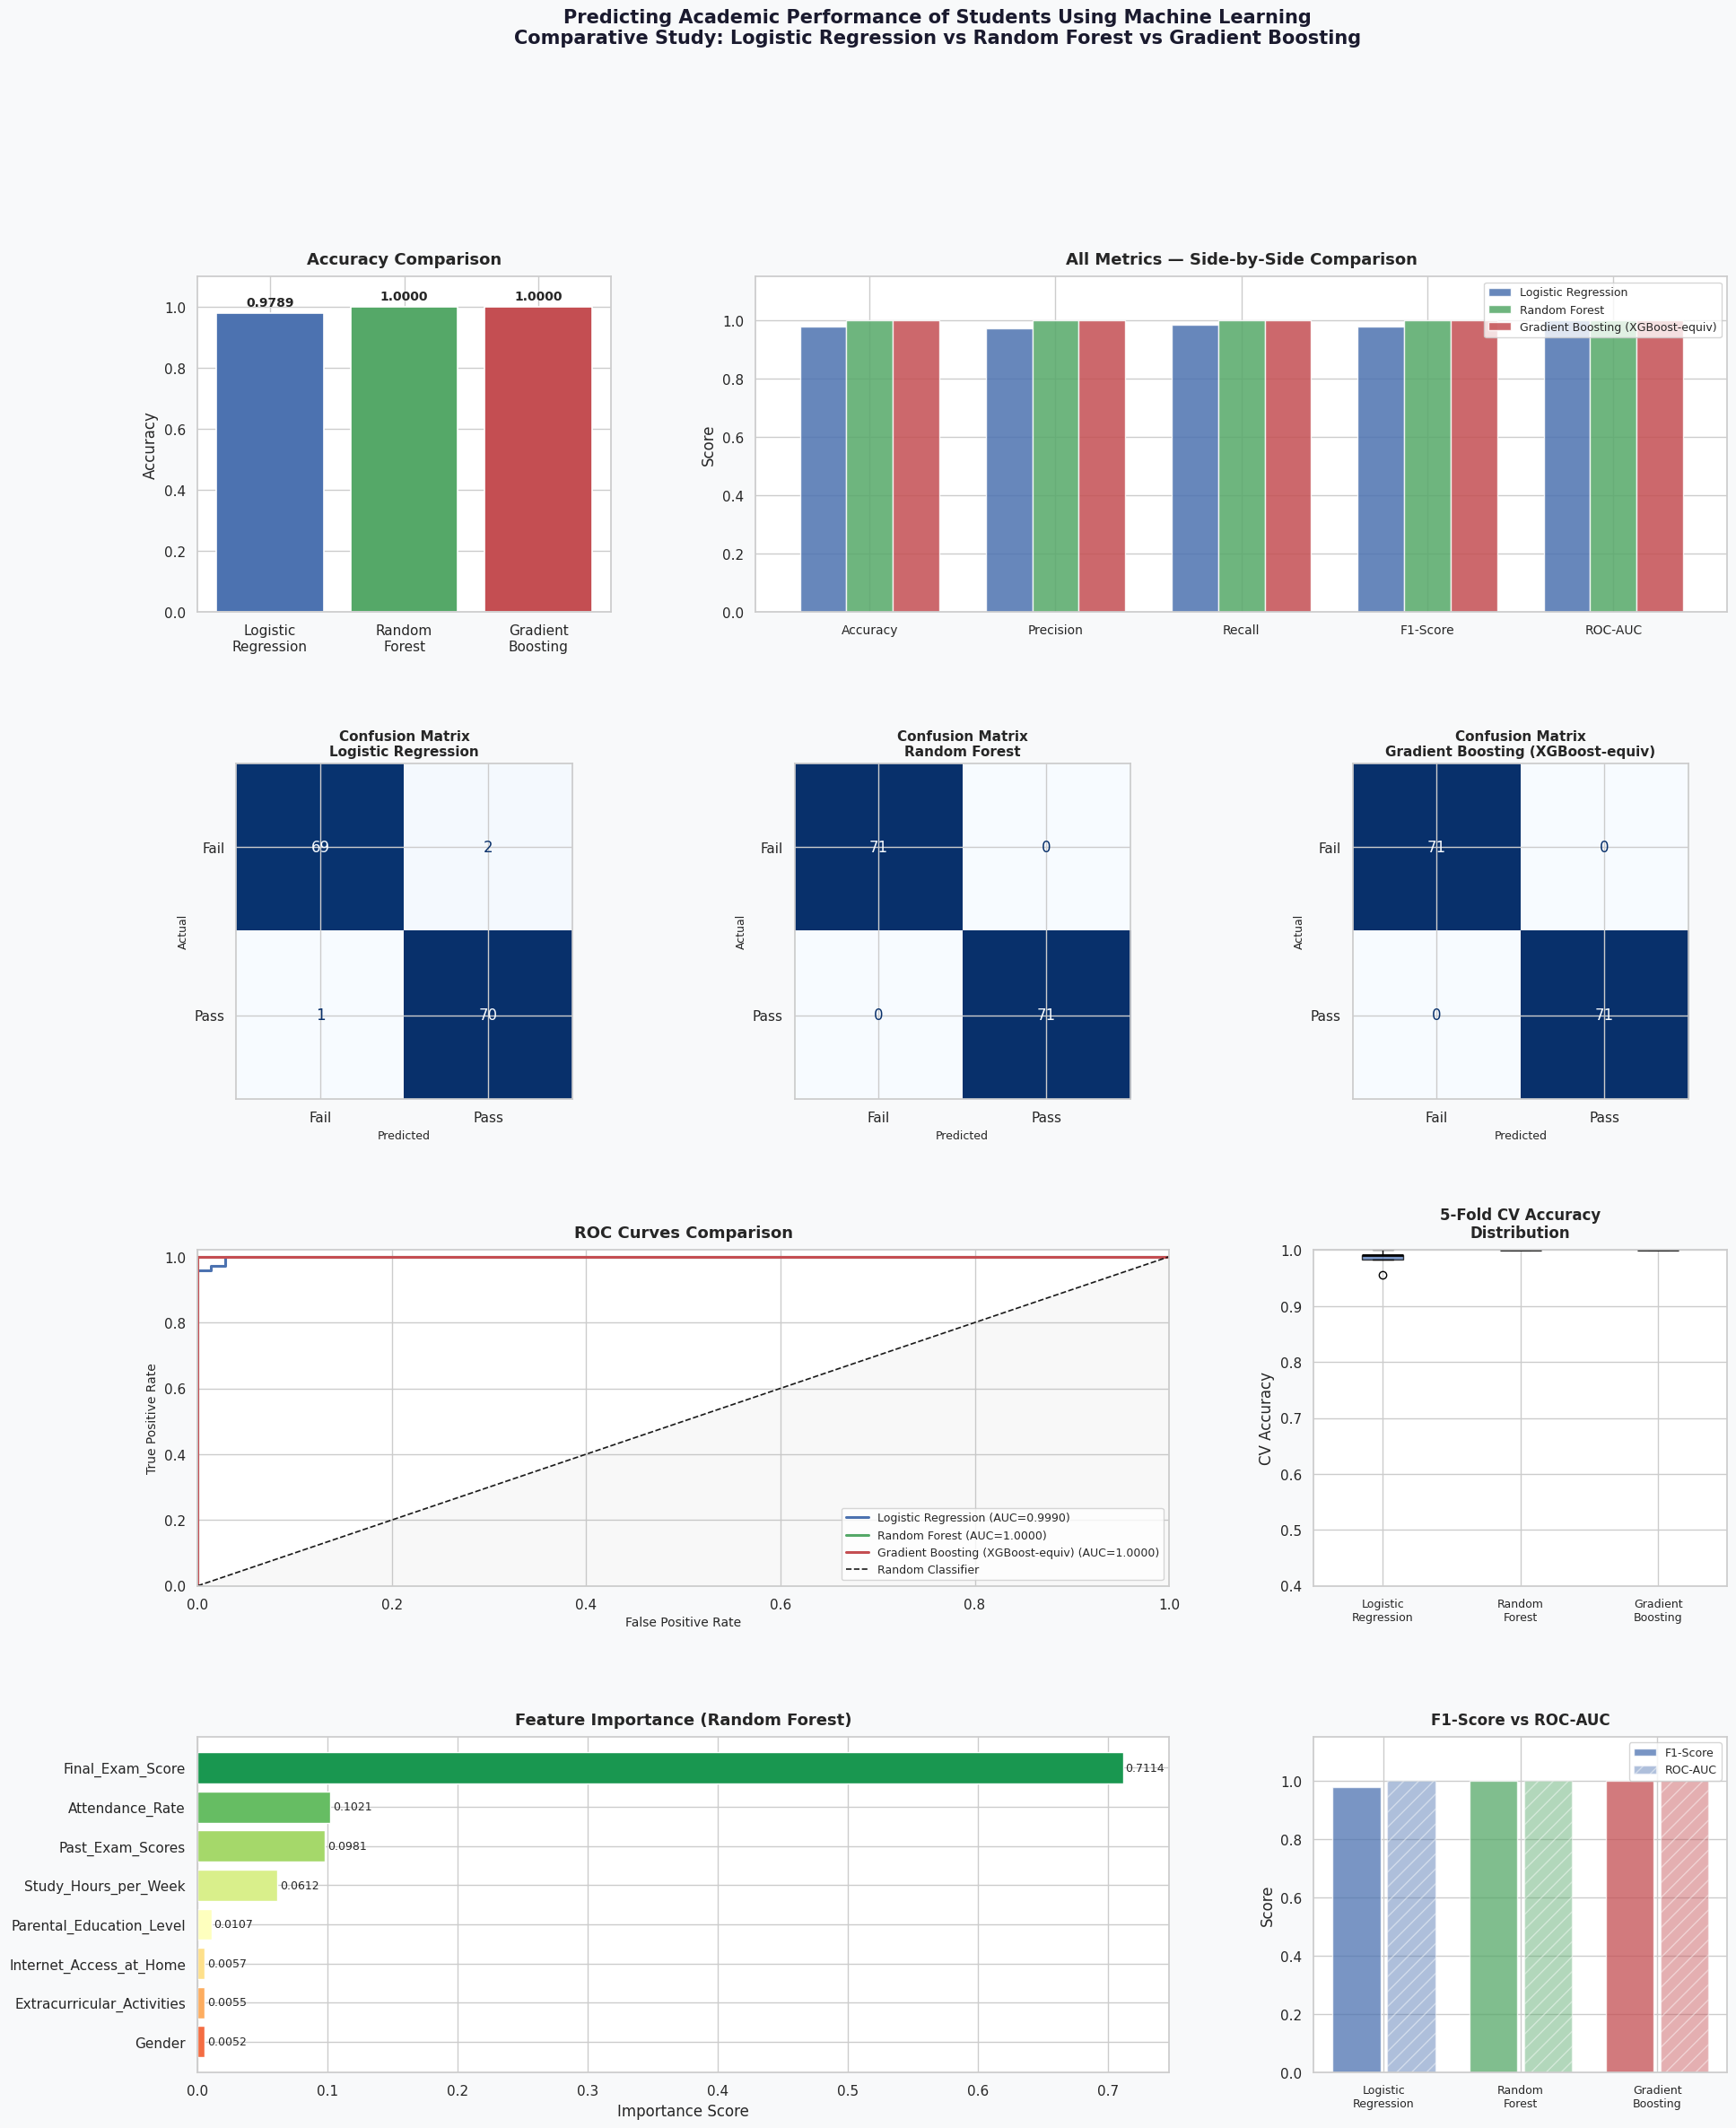

In [ ]:
sns.set_theme(style='whitegrid', palette='muted')
colors = ['#4C72B0', '#55A868', '#C44E52']   # blue, green, red

fig = plt.figure(figsize=(22, 26))
fig.patch.set_facecolor('#F8F9FA')
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)

short_labels = ['Logistic\nRegression', 'Random\nForest', 'Gradient\nBoosting']

# ── Plot 1: Accuracy Bar Chart ──────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
accs = [results[k.replace('\n', ' ')]['Accuracy'] for k in model_labels]
bars = ax1.bar(short_labels, accs, color=colors, edgecolor='white', linewidth=1.2)
ax1.set_ylim(0, 1.1)
ax1.set_title('Accuracy Comparison', fontsize=13, fontweight='bold', pad=10)
ax1.set_ylabel('Accuracy')
for bar, val in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Plot 2: All Metrics Grouped Bar ─────────────────────────
ax2 = fig.add_subplot(gs[0, 1:])
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x       = np.arange(len(metrics))
width   = 0.25
for i, (label, color) in enumerate(zip(model_labels, colors)):
    vals = [results[label.replace('\n', ' ')][m] for m in metrics]
    ax2.bar(x + i*width, vals, width, label=label.replace('\n', ' '),
            color=color, alpha=0.85, edgecolor='white')
ax2.set_xticks(x + width)
ax2.set_xticklabels(metrics, fontsize=10)
ax2.set_ylim(0, 1.15)
ax2.set_title('All Metrics — Side-by-Side Comparison', fontsize=13, fontweight='bold', pad=10)
ax2.set_ylabel('Score')
ax2.legend(fontsize=9, loc='upper right')

# ── Plots 3-5: Confusion Matrices ───────────────────────────
for i, (label, color) in enumerate(zip(model_labels, colors)):
    ax = fig.add_subplot(gs[1, i])
    cm = conf_matrices[label.replace('\n', ' ')]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix\n{label.replace(chr(10), " ")}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)

# ── Plot 6: ROC Curves ──────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 0:2])
for label, color in zip(model_labels, colors):
    fpr, tpr, auc = roc_data[label.replace('\n', ' ')]
    ax6.plot(fpr, tpr, color=color, lw=2.2,
             label=f'{label.replace(chr(10)," ")} (AUC={auc:.4f})')
ax6.plot([0,1],[0,1], 'k--', lw=1.2, label='Random Classifier')
ax6.set_xlim([0,1]); ax6.set_ylim([0,1.02])
ax6.set_xlabel('False Positive Rate', fontsize=10)
ax6.set_ylabel('True Positive Rate', fontsize=10)
ax6.set_title('ROC Curves Comparison', fontsize=13, fontweight='bold', pad=10)
ax6.legend(fontsize=9, loc='lower right')
ax6.fill_between([0,1],[0,1], alpha=0.05, color='grey')

# ── Plot 7: Cross-Validation Score Boxplot ──────────────────
ax7 = fig.add_subplot(gs[2, 2])
cv_data = [cv_scores[k.replace('\n', ' ')] for k in model_labels]
bp = ax7.boxplot(cv_data, patch_artist=True, notch=False,
                 medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax7.set_xticklabels(short_labels, fontsize=9)
ax7.set_title('5-Fold CV Accuracy\nDistribution', fontsize=12, fontweight='bold', pad=10)
ax7.set_ylabel('CV Accuracy')
ax7.set_ylim(0.4, 1.0)

# ── Plot 8: Feature Importance (Random Forest) ──────────────
ax8 = fig.add_subplot(gs[3, 0:2])
rf_model  = models['Random Forest']
feat_imp  = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
colors_feat = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp)))
bars = ax8.barh(feat_imp.index, feat_imp.values, color=colors_feat, edgecolor='white')
ax8.set_title('Feature Importance (Random Forest)', fontsize=13, fontweight='bold', pad=10)
ax8.set_xlabel('Importance Score')
for bar, val in zip(bars, feat_imp.values):
    ax8.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

# ── Plot 9: F1-Score & ROC-AUC Comparison ───────────────────
ax9 = fig.add_subplot(gs[3, 2])
f1s  = [results[k.replace('\n', ' ')]['F1-Score'] for k in model_labels]
aucs = [results[k.replace('\n', ' ')]['ROC-AUC']  for k in model_labels]
x9   = np.arange(len(short_labels))
ax9.bar(x9 - 0.2, f1s,  0.35, label='F1-Score',  color=colors, alpha=0.75, edgecolor='white')
ax9.bar(x9 + 0.2, aucs, 0.35, label='ROC-AUC',   color=colors, alpha=0.45, edgecolor='white', hatch='//')
ax9.set_xticks(x9); ax9.set_xticklabels(short_labels, fontsize=9)
ax9.set_ylim(0, 1.15); ax9.set_ylabel('Score')
ax9.set_title('F1-Score vs ROC-AUC', fontsize=12, fontweight='bold', pad=10)
ax9.legend(fontsize=9)

# ── Main Title ───────────────────────────────────────────────
fig.suptitle(
    'Predicting Academic Performance of Students Using Machine Learning\n'
    'Comparative Study: Logistic Regression vs Random Forest vs Gradient Boosting',
    fontsize=15, fontweight='bold', y=0.995, color='#1a1a2e'
)

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay

sns.set_theme(style='whitegrid', palette='muted')

colors = ['#4C72B0', '#55A868', '#C44E52']
short_labels = ['Logistic\nRegression', 'Random\nForest', 'Gradient\nBoosting']

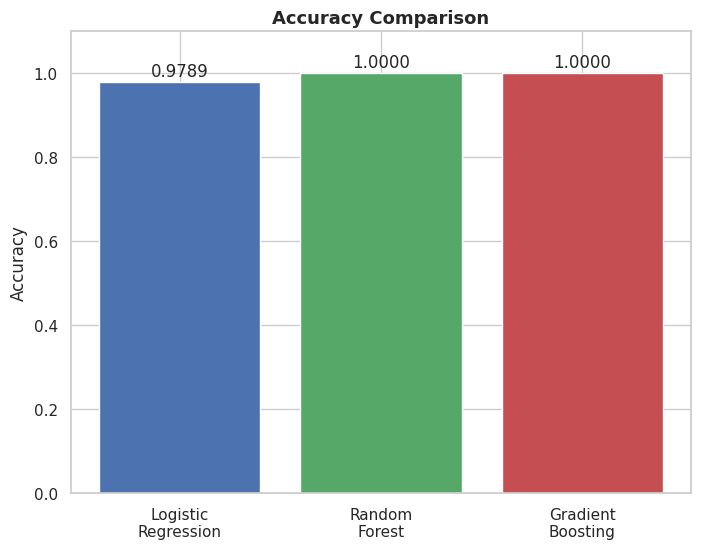

In [ ]:
plt.figure(figsize=(8,6))

accs = [results[k.replace('\n', ' ')]['Accuracy'] for k in model_labels]

bars = plt.bar(short_labels, accs, color=colors, edgecolor='white')

plt.title('Accuracy Comparison', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0,1.1)

for bar, val in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.015,
             f'{val:.4f}',
             ha='center')

plt.show()

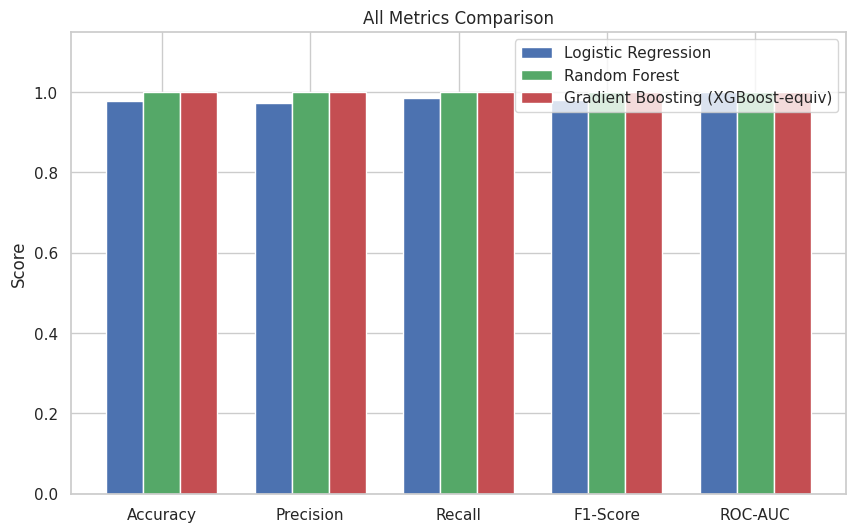

In [ ]:
plt.figure(figsize=(10,6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

for i,(label,color) in enumerate(zip(model_labels,colors)):

    vals = [results[label.replace('\n',' ')][m] for m in metrics]

    plt.bar(x+i*width, vals, width,
            label=label.replace('\n',' '),
            color=color)

plt.xticks(x+width, metrics)
plt.ylim(0,1.15)
plt.ylabel('Score')
plt.title('All Metrics Comparison')
plt.legend()

plt.show()

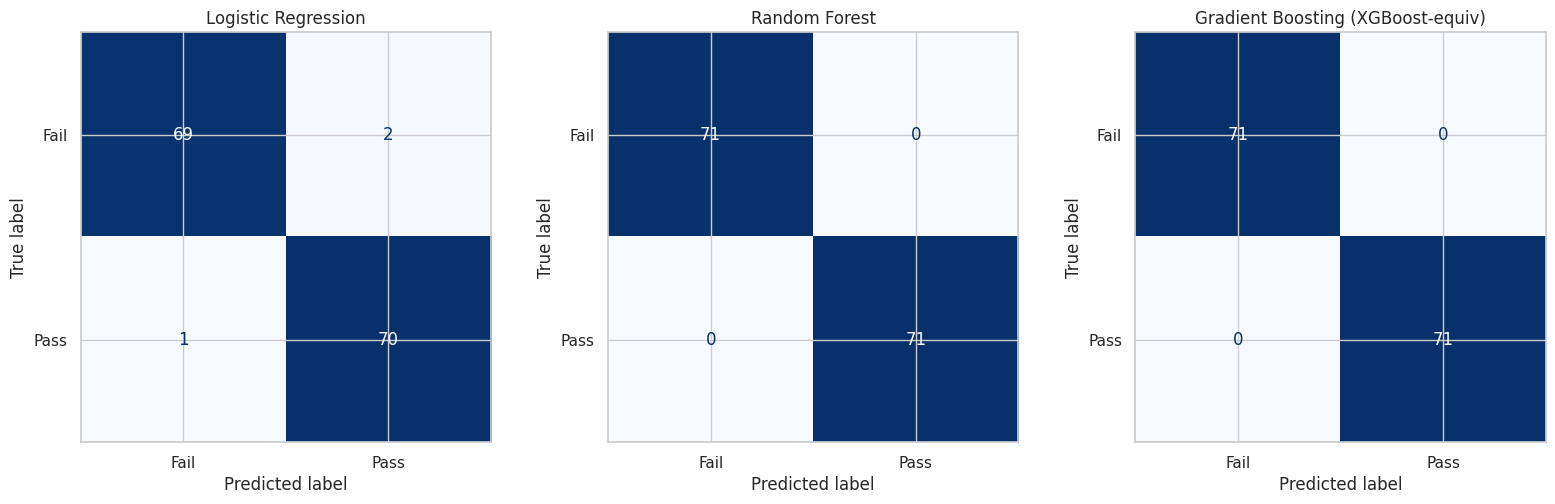

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(16,5))

for ax,(label,color) in zip(axes, zip(model_labels,colors)):

    cm = conf_matrices[label.replace('\n',' ')]

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Fail','Pass']
    )

    disp.plot(ax=ax, colorbar=False, cmap='Blues')

    ax.set_title(label.replace('\n',' '))

plt.tight_layout()
plt.show()

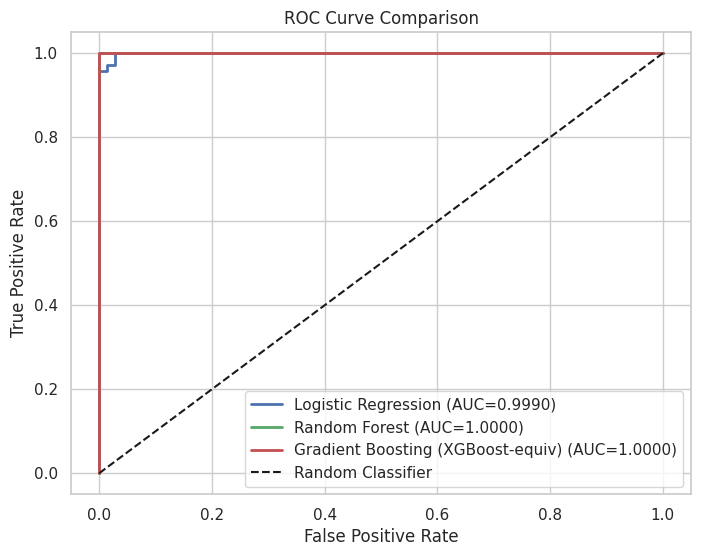

In [ ]:
plt.figure(figsize=(8,6))

for label,color in zip(model_labels,colors):

    fpr,tpr,auc = roc_data[label.replace('\n',' ')]

    plt.plot(fpr,tpr,
             color=color,
             lw=2,
             label=f'{label.replace(chr(10)," ")} (AUC={auc:.4f})')

plt.plot([0,1],[0,1],'k--',label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve Comparison')

plt.legend()

plt.show()

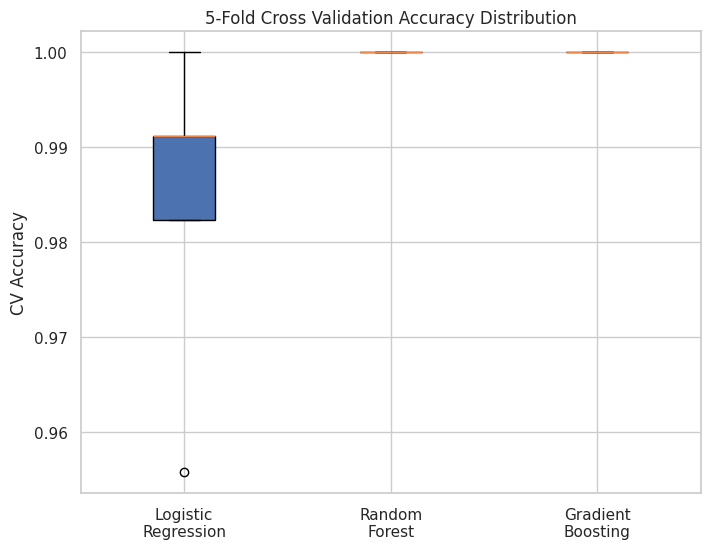

In [ ]:
plt.figure(figsize=(8,6))

cv_data = [cv_scores[k.replace('\n',' ')] for k in model_labels]

bp = plt.boxplot(cv_data, patch_artist=True)

for patch,color in zip(bp['boxes'],colors):
    patch.set_facecolor(color)

plt.xticks(range(1,4), short_labels)

plt.ylabel('CV Accuracy')

plt.title('5-Fold Cross Validation Accuracy Distribution')

plt.show()

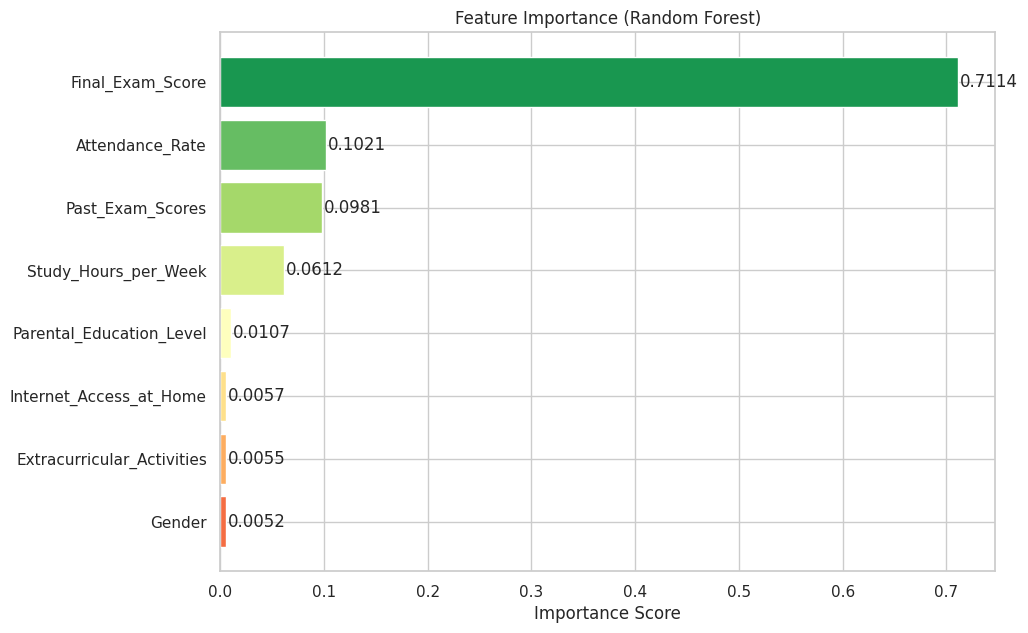

In [ ]:
plt.figure(figsize=(10,7))

rf_model = models['Random Forest']

feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values()

colors_feat = plt.cm.RdYlGn(np.linspace(0.2,0.9,len(feat_imp)))

bars = plt.barh(feat_imp.index,
                feat_imp.values,
                color=colors_feat)

plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')

for bar,val in zip(bars,feat_imp.values):
    plt.text(val+0.002,
             bar.get_y()+bar.get_height()/2,
             f'{val:.4f}',
             va='center')

plt.show()

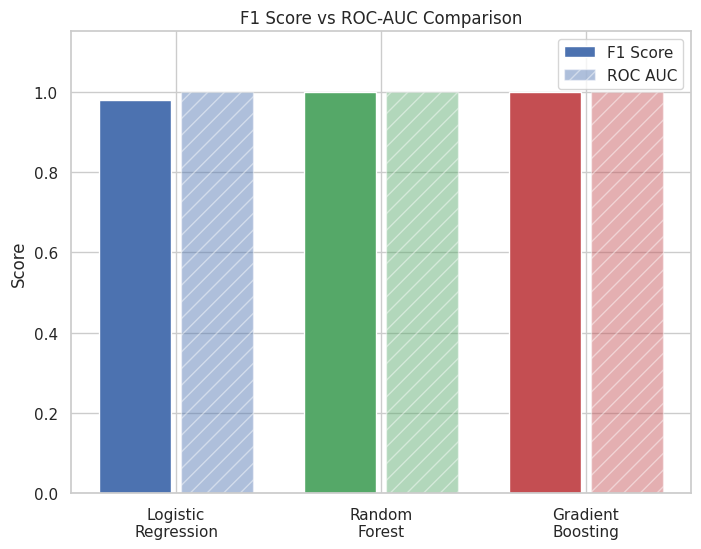

In [ ]:
plt.figure(figsize=(8,6))

f1s  = [results[k.replace('\n',' ')]['F1-Score'] for k in model_labels]
aucs = [results[k.replace('\n',' ')]['ROC-AUC'] for k in model_labels]

x = np.arange(len(short_labels))

plt.bar(x-0.2, f1s, 0.35,
        label='F1 Score',
        color=colors)

plt.bar(x+0.2, aucs, 0.35,
        label='ROC AUC',
        color=colors,
        alpha=0.45,
        hatch='//')

plt.xticks(x,short_labels)

plt.ylabel('Score')
plt.ylim(0,1.15)

plt.title('F1 Score vs ROC-AUC Comparison')

plt.legend()

plt.show()

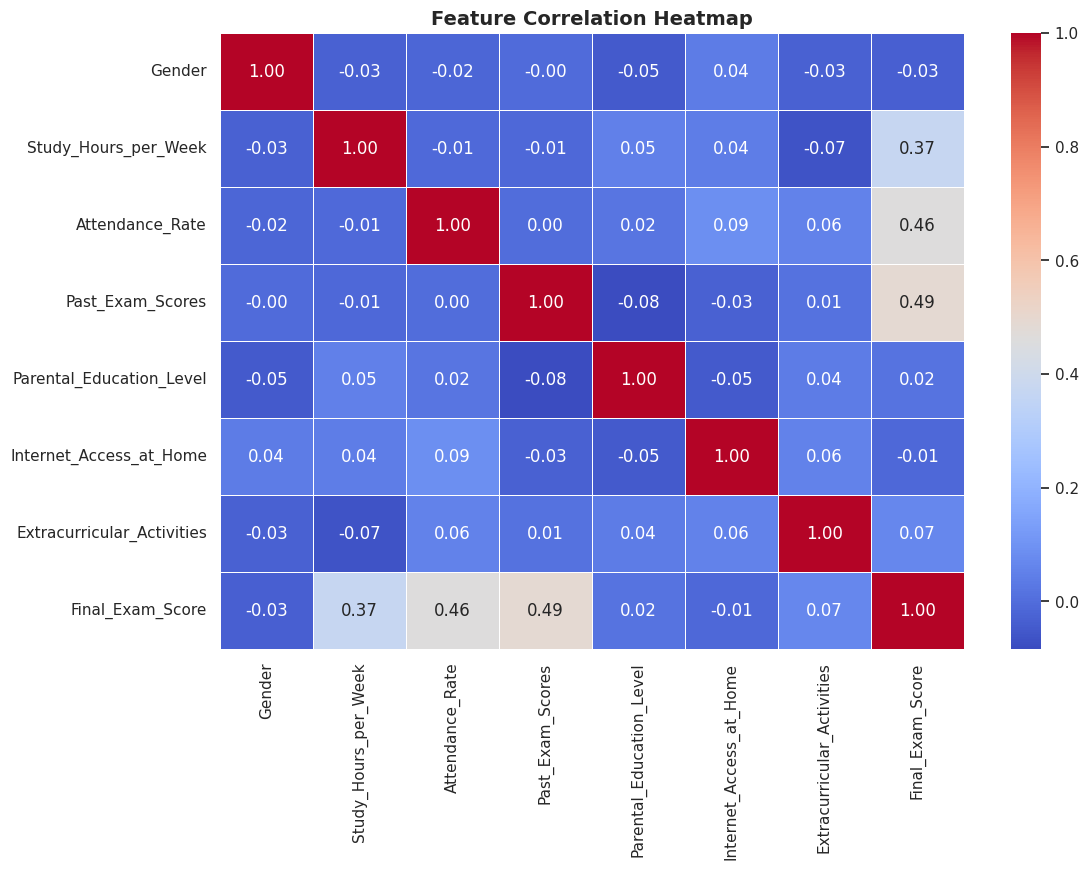

In [ ]:
plt.figure(figsize=(12,8))

# Compute correlation matrix
corr_matrix = X.corr()

# Plot heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')

plt.show()